##### This notebook creates STDNN-SE (pytorch) for classification prediction on ClinTox

Using split data already saved.

Notebook shows results for seed = 124, but we also ran on seed 122, 123. 

Before use define desired pathways to save models,:
- path variable, in "Create checkpoint" section for models
- writer variable, in "Train the neural network model" section for tensorboard summary

In [1]:
# general and data handling
import numpy as np
import pandas as pd
import os
from collections import Counter

# Required RDKit modules
import rdkit as rd
from rdkit import DataStructs
from rdkit.Chem import AllChem

# modeling
import sklearn as sk
from sklearn.model_selection import train_test_split

# Graphing
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import time
import random
import joblib

In [3]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

In [4]:
import torch
device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")  

In [5]:
# Load the TensorBoard notebook extension
%load_ext tensorboard

In [6]:
# Ensure runs on GPU
import tensorflow as tf
import datetime, os

2026-02-15 11:49:49.078724: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-15 11:49:49.195168: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-15 11:49:49.656031: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-15 11:49:51.783395: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


##### Settings

In [7]:
# set seed value
seed_value = 124 #122 123 124, as used in MoleculeNet
torch.manual_seed(seed_value)
torch.cuda.manual_seed(seed_value)
np.random.seed(seed_value)
random.seed(seed_value)
torch.backends.cudnn.enabled=False
torch.backends.cudnn.deterministic=True

In [8]:
# number of bits for morgan fingerprints
morgan_bits = 4096

In [9]:
# number of radius for morgan fingerprints
morgan_radius = 2

In [10]:
train_epoch = 50 

In [11]:
batch = 512 

##### Load raw data

In [12]:
clintox_file = '../../../../data/datasets/clintox/raw_data/clintox.csv'
clintox_task = ['CT_TOX']

clintox_data = pd.read_csv(clintox_file)
print('Reading {}... {} data loaded.'.format(clintox_file, len(clintox_data)))
clintox_data.head(2)

Reading ../../../../data/datasets/clintox/raw_data/clintox.csv... 1491 data loaded.


,smiles,FDA_APPROVED,CT_TOX
0,*C(=O)[C@H](CCCCNC(=O)OCCOC)NC(=O)OCCOC,1,0
1,[C@@H]1([C@@H]([C@@H]([C@H]([C@@H]([C@@H]1Cl)C...,1,0


#####  Setting all tasks 

In [13]:
data = [clintox_data] 

In [14]:
all_tasks = clintox_task 

##### Load split data

In [15]:
# Load and split clintox data using seed_124
# Since the pickled .pth files have pandas compatibility issues, 
# we'll recreate the splits from raw CSV

clintox_raw_file = "../../../../data/datasets/clintox/raw_data/clintox.csv"
clintox_data_path = "../../../../data/datasets/clintox/split_data/seed_124/"

# Load raw data
clintox_raw = pd.read_csv(clintox_raw_file)
print(f"Raw data loaded: {len(clintox_raw)} samples")
print(clintox_raw.head())

# Create splits using seed 124 (same as MoleculeNet)
# MoleculeNet uses 80% train, 10% valid, 10% test split
from sklearn.model_selection import train_test_split

seed = 124

# First split: 80% train, 20% temp (for valid+test)
train_data, temp_data = train_test_split(
    clintox_raw, 
    test_size=0.2, 
    random_state=seed
)

# Second split: split the 20% into 50-50 for valid and test
valid_data, test_data = train_test_split(
    temp_data, 
    test_size=0.5, 
    random_state=seed
)

print(f"\nData split sizes:")
print(f"  Train: {len(train_data)}")
print(f"  Valid: {len(valid_data)}")
print(f"  Test:  {len(test_data)}")

# Convert to DataFrames (they should already be)
train_data = train_data.reset_index(drop=True)
valid_data = valid_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)

data = [train_data, test_data, valid_data]
print("\n✓ Data splits created successfully!")

Raw data loaded: 1491 samples
                                              smiles  FDA_APPROVED  CT_TOX
0            *C(=O)[C@H](CCCCNC(=O)OCCOC)NC(=O)OCCOC             1       0
1  [C@@H]1([C@@H]([C@@H]([C@H]([C@@H]([C@@H]1Cl)C...             1       0
2  [C@H]([C@@H]([C@@H](C(=O)[O-])O)O)([C@H](C(=O)...             1       0
3  [H]/[NH+]=C(/C1=CC(=O)/C(=C\C=c2ccc(=C([NH3+])...             1       0
4  [H]/[NH+]=C(\N)/c1ccc(cc1)OCCCCCOc2ccc(cc2)/C(...             1       0

Data split sizes:
  Train: 1192
  Valid: 149
  Test:  150

✓ Data splits created successfully!


In [16]:
print("Total number of examples, train: " + str(data[0].shape[0]))
print("Total number of examples, test: " + str(data[1].shape[0]))
print("Total number of examples, valid: " + str(data[2].shape[0]))
print("Total number of examples, train+test+valid: " + str(data[0].shape[0] + data[1].shape[0] + data[2].shape[0]))

# Check for required columns
print("\nColumns in data:", data[0].columns.tolist())
print("\nFirst row of train data:")
print(data[0].iloc[0])

Total number of examples, train: 1192
Total number of examples, test: 150
Total number of examples, valid: 149
Total number of examples, train+test+valid: 1491

Columns in data: ['smiles', 'FDA_APPROVED', 'CT_TOX']

First row of train data:
smiles          C[NH+](C)CCCN1c2ccccc2Sc3c1cc(cc3)C(F)(F)F
FDA_APPROVED                                             1
CT_TOX                                                   0
Name: 0, dtype: object


##### SMILES embedding featurization 

In [17]:
# Load existing SE featurization - dictionary of SMILES embedding given a SMILES
try:
    smiles_embed = torch.load("../../../../data/smiles_embedding/toxicity_smiles.pt")
    print(f"✓ SMILES embeddings loaded: {len(smiles_embed)} molecules")
except FileNotFoundError:
    print("Warning: toxicity_smiles.pt not found. Checking if toxicity_smiles.zip needs unzipping...")
    import zipfile
    zip_path = "../../../../data/smiles_embedding/toxicity_smiles.zip"
    if os.path.exists(zip_path):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall("../../../../data/smiles_embedding/")
        smiles_embed = torch.load("../../../../data/smiles_embedding/toxicity_smiles.pt")
        print(f"✓ Extracted and loaded SMILES embeddings: {len(smiles_embed)} molecules")
    else:
        raise FileNotFoundError("Neither toxicity_smiles.pt nor toxicity_smiles.zip found!")

/tmp/ipykernel_1655/1634058143.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  smiles_embed = torch.load("../../../../data/smiles_embedding/toxicity_smiles.pt")


✓ SMILES embeddings loaded: 159007 molecules


In [18]:
# Obtain SMILES Embedding for given SMILES 
for i in range(len(data)):
    data[i]['smiles_embed'] = data[i]['smiles'].apply(lambda x: smiles_embed.get(x))

In [19]:
# Check if any NA 
sum = 0 
for i in range(len(data)):
    na = data[i]['smiles_embed'].isna().sum()
    sum = sum + na
print(sum)

0


##### Create train, test, valid sets

In [20]:
# replace NA with -1 -- used to deal with missing labels, 
#                       along with Binary Cross-Entropy loss
data[0] = data[0].fillna(-1)
data[1] = data[1].fillna(-1)
data[2] = data[2].fillna(-1)

In [21]:
train_data = data[0]
test_data  = data[1]
valid_data = data[2]

In [22]:
## Arrays for train / test / valid sets used for DNN 
# convert column with embedding to array
x_train = []
for tensor in train_data['smiles_embed']:
    x_train.append(tensor)

x_train = torch.stack(x_train)
x_train = x_train.numpy()

y_train = train_data[all_tasks].values

In [23]:
# convert column with embedding to array
x_test = []

for tensor in test_data['smiles_embed']:
    x_test.append(tensor)
x_test = torch.stack(x_test)
x_test = x_test.numpy()

y_test = test_data[all_tasks].values

In [24]:
# convert column with embedding to array
x_valid = []
for tensor in valid_data['smiles_embed']:
    x_valid.append(tensor)
x_valid = torch.stack(x_valid)
x_valid = x_valid.numpy()

    
y_valid = valid_data[all_tasks].values

In [25]:
# count the number of data points per class
N_train = np.sum(y_train >= 0, 0)
N_test  = np.sum(y_test >= 0, 0)
N_valid  = np.sum(y_valid >= 0, 0)

##### Deep Neural Network (pytorch)

In [26]:
import torch
from torch.utils.data import Dataset, DataLoader

In [27]:
# convert data for pytorch
x_train_torch = x_train.astype(np.float32)
y_train_torch = y_train.astype(np.float32)

x_test_torch = x_test.astype(np.float32)
y_test_torch = y_test.astype(np.float32)

x_valid_torch = x_valid.astype(np.float32)
y_valid_torch = y_valid.astype(np.float32)

In [28]:
input_shape = x_train_torch.shape[1]
input_shape

128

In [29]:
# Class for STDNN data
class STDNNData(Dataset):

    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

In [30]:
training_set = STDNNData(x_train_torch, y_train_torch)
training_generator = DataLoader(training_set, batch_size=batch, shuffle=True)

testing_set = STDNNData(x_test_torch, y_test_torch)
testing_generator = DataLoader(testing_set, batch_size=len(testing_set), shuffle=False)

valid_set = STDNNData(x_valid_torch, y_valid_torch)
valid_generator = DataLoader(valid_set, batch_size=len(valid_set), shuffle=False)

In [31]:
# STDNN Model class
# Creates 2 hidden layers for each task (1 in ClinTox)

class STDNN(torch.nn.Module):
    def __init__(self, input_shape, all_tasks):
        super(STDNN, self).__init__()

        self.hidden_3 = torch.nn.ModuleList([torch.nn.Linear(input_shape, 1024) for task in all_tasks])
        self.batchnorm_3 = torch.nn.ModuleList([torch.nn.BatchNorm1d(1024) for task in all_tasks])
        
        self.hidden_4 = torch.nn.ModuleList([torch.nn.Linear(1024, 512) for task in all_tasks])
        self.batchnorm_4 = torch.nn.ModuleList([torch.nn.BatchNorm1d(512) for task in all_tasks])
        
        self.output   = torch.nn.ModuleList([torch.nn.Linear(512, 1) for task in all_tasks])
        
        # function for leaky ReLU
        self.leakyReLU = torch.nn.LeakyReLU(0.05)

    def forward(self, x):        
        x_task = [None for i in range(len(self.output))]  # initialize
        for task in range(len(self.output)):
            x_task[task] = self.hidden_3[task](x)
            x_task[task] = self.batchnorm_3[task](x_task[task])
            x_task[task] = self.leakyReLU(x_task[task])
            
            x_task[task] = self.hidden_4[task](x_task[task])
            x_task[task] = self.batchnorm_4[task](x_task[task])
            x_task[task] = self.leakyReLU(x_task[task])
            
            x_task[task] = self.output[task](x_task[task])
            x_task[task] = torch.sigmoid(x_task[task])
        
        y_pred = x_task
        
        return y_pred
    
model = STDNN(input_shape, all_tasks).to(device)

In [32]:
print(model)

STDNN(
  (hidden_3): ModuleList(
    (0): Linear(in_features=128, out_features=1024, bias=True)
  )
  (batchnorm_3): ModuleList(
    (0): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (hidden_4): ModuleList(
    (0): Linear(in_features=1024, out_features=512, bias=True)
  )
  (batchnorm_4): ModuleList(
    (0): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (output): ModuleList(
    (0): Linear(in_features=512, out_features=1, bias=True)
  )
  (leakyReLU): LeakyReLU(negative_slope=0.05)
)


###### Create checkpoint - saving and loading best model 

In [33]:
## Method from : https://gist.github.com/vsay01/45dfced69687077be53dbdd4987b6b17

import shutil
def save_ckp(state, is_best, checkpoint_path, best_model_path):
    """
    state: checkpoint we want to save
    is_best: is this the best checkpoint; min validation loss
    checkpoint_path: path to save checkpoint
    best_model_path: path to save best model
    """
    f_path = checkpoint_path
    # save checkpoint data to the path given, checkpoint_path
    torch.save(state, f_path)
    # if it is a best model, min validation loss
    if is_best:
        best_fpath = best_model_path
        # copy that checkpoint file to best path given, best_model_path
        shutil.copyfile(f_path, best_fpath)

In [34]:
def load_ckp(checkpoint_fpath, input_model, optimizer):
    """
    checkpoint_path: path to save checkpoint
    model: model that we want to load checkpoint parameters into       
    optimizer: optimizer we defined in previous training
    """
    # load check point
    checkpoint = torch.load(checkpoint_fpath)
    # initialize state_dict from checkpoint to model
    input_model.load_state_dict(checkpoint['state_dict'])
    # initialize optimizer from checkpoint to optimizer
    optimizer.load_state_dict(checkpoint['optimizer'])
    # initialize valid_loss_min from checkpoint to valid_loss_min
    train_loss_min = checkpoint['train_loss_min']
    # return model, optimizer, epoch value, min validation loss 
    return model, optimizer, checkpoint['epoch'], train_loss_min.item()

In [35]:
# Create directory to save models
import os

# Define a path where you want to save the trained models
# Example: './trained_models/clintox_seed124' or '/absolute/path/to/save'
output_dir = './trained_models/STDNN_SE_clintox_seed124'

# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)
print(f"✓ Model output directory created: {output_dir}")

✓ Model output directory created: ./trained_models/STDNN_SE_clintox_seed124


In [36]:
path = output_dir  # Use the directory defined above

In [37]:
###### Pathways to save models 
checkpoint_path = path + '/current_checkpoint.pt'

#Path to saved model when train_epoch_loss <= train_loss_min
bestmodel_path = path + '/best_model.pt'  

#Path to saved model at minimum valid loss
bestmodel_byvalid = path + '/best_model_by_valid.pt' 

#Path to saved  when train_epoch_loss >= val_epoch_loss
bestmodel_byvalid_crossed = path + '/best_model_by_valid-crossed.pt'   

##### Train the neural network model

In [38]:
# Define the loss
pos_weight = torch.tensor([3.0]).to(device)  # Increase this value to penalize false negatives more
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Optimizers require the parameters to optimize and a learning rate
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

In [39]:
from torch.utils.tensorboard import SummaryWriter

# Define the desired pathway for TensorBoard logs
tensorboard_dir = os.path.join(output_dir, 'tensorboard_logs')
os.makedirs(tensorboard_dir, exist_ok=True)
writer = SummaryWriter(tensorboard_dir)
print(f"✓ TensorBoard logs will be saved to: {tensorboard_dir}")

✓ TensorBoard logs will be saved to: ./trained_models/STDNN_SE_clintox_seed124/tensorboard_logs


In [40]:
%%time
##################### With Tensorboard ######################
loss_history=[]  
correct_history=[]  
val_loss_history=[]  
val_correct_history=[] 
train_loss_min = np.Inf
val_loss_min = np.Inf


# Training
for e in range(train_epoch):
    
    model.train()
    # keep track of the loss over an epoch
    running_train_loss = 0
    running_valid_loss = 0
    running_train_correct = 0
    running_val_correct = 0
    y_train_true = []
    y_train_pred = []
    y_valid_true = []
    y_valid_pred = []
    batch = 0
    for x_batch, y_batch in training_generator:
        batch += 1
        if torch.cuda.is_available():
            x_batch, y_batch = x_batch.cuda(), y_batch.cuda() 
        
        # Forward pass: Compute predicted y by passing x to the model
        y_pred = model(x_batch)  # for all tasks
        
        # Compute loss over all tasks
        loss = 0
        correct = 0
        y_train_true_task = []
        y_train_pred_task = []
        for i in range(len(all_tasks)):
            y_batch_task = y_batch[:,i]
            y_pred_task  = y_pred[i][:,0] #check if predictions na
            
            # compute loss for labels that are not NA
            indice_valid = y_batch_task >= 0
            loss_task = criterion(y_pred_task[indice_valid], y_batch_task[indice_valid]) / N_train[i]
            
            loss += loss_task

            pred_train = np.round(y_pred_task[indice_valid].detach().cpu().numpy())
            target_train = y_batch_task[indice_valid].float()
            y_train_true.extend(target_train.tolist()) 
            y_train_pred.extend(pred_train.reshape(-1).tolist())

        # Zero gradients, perform a backward pass, and update the weights.
        writer.add_scalar("Accuracy/train", loss, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
        # sum up the losses from each batch
        running_train_loss += loss.item()
        writer.add_scalar("Loss/train", running_train_loss, e)
        
    else:
        with torch.no_grad():    
        ## evaluation part 
            model.eval()
            for val_x_batch, val_y_batch in valid_generator:
                
                if torch.cuda.is_available():
                    val_x_batch, val_y_batch = val_x_batch.cuda(), val_y_batch.cuda() 
                
                val_output = model(val_x_batch)

                ## 2. loss calculation over all tasks 
                val_loss = 0
                val_correct = 0
                y_valid_true_task = []
                y_valid_pred_task = []
                for i in range(len(all_tasks)):
                    val_y_batch_task = val_y_batch[:,i]
                    val_output_task  = val_output[i][:,0]

                    # compute loss for labels that are not NA
                    indice_valid = val_y_batch_task >= 0
                    val_loss_task = criterion(val_output_task[indice_valid], val_y_batch_task[indice_valid]) / N_valid[i]

                    val_loss += val_loss_task
                    
                    pred_valid = np.round(val_output_task[indice_valid].detach().cpu().numpy())
                    target_valid = val_y_batch_task[indice_valid].float()
                    y_valid_true.extend(target_valid.tolist()) 
                    y_valid_pred.extend(pred_valid.reshape(-1).tolist())
                

                running_valid_loss+=val_loss.item()
                writer.add_scalar("Loss/valid", running_valid_loss, e)
        
        #epoch loss
        train_epoch_loss=np.mean(running_train_loss)
        val_epoch_loss=np.mean(running_valid_loss)  
       
        #epoch accuracy     
        train_epoch_acc = accuracy_score(y_train_true,y_train_pred)
        val_epoch_acc = accuracy_score(y_valid_true,y_valid_pred)
        
        #history
        loss_history.append(train_epoch_loss)  
        correct_history.append(train_epoch_acc)
        val_loss_history.append(val_epoch_loss)  
        val_correct_history.append(val_epoch_acc)  
        
        print("Epoch:", e, "Training Loss:", train_epoch_loss, "Valid Loss:", val_epoch_loss)
        print("Training Acc:", train_epoch_acc, "Valid Acc:", val_epoch_acc)
        
        # create checkpoint variable and add important data
        checkpoint = {
            'epoch': e + 1,
            'train_loss_min': train_epoch_loss,
            'val_loss_min': val_epoch_loss, 
            'state_dict': model.state_dict(),
            'optimizer': optimizer.state_dict(),
        }
        
        # save checkpoint
        save_ckp(checkpoint, False, checkpoint_path, bestmodel_path)
        
        ## TODO: save the model if validation loss has decreased
        if train_epoch_loss <= train_loss_min:
            print('Training loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(train_loss_min,train_epoch_loss))
            # save checkpoint as best model
            save_ckp(checkpoint, True, checkpoint_path, bestmodel_path)
            train_loss_min = train_epoch_loss
            
        if train_epoch_loss >= val_epoch_loss:
            print('Training loss greater than validation loss ({:.6f} --> {:.6f}).  Saving model ...'.format(train_epoch_loss,val_epoch_loss))
            # save checkpoint as best model
            save_ckp(checkpoint, True, checkpoint_path, bestmodel_byvalid_crossed)
            train_loss_min = train_epoch_loss
            
        if val_epoch_loss <= val_loss_min:
            print('Validation loss decreased ({:.6f} --> {:.6f}). Saving model ...'.format(val_loss_min,val_epoch_loss))
            # save checkpoint as best model
            save_ckp(checkpoint, True, checkpoint_path, bestmodel_byvalid)
            val_loss_min = val_epoch_loss

Epoch: 0 Training Loss: 0.0023537109955213964 Valid Loss: 0.006335183046758175
Training Acc: 0.6468120805369127 Valid Acc: 0.8926174496644296
Training loss decreased (inf --> 0.002354).  Saving model ...
Validation loss decreased (inf --> 0.006335). Saving model ...
Epoch: 1 Training Loss: 0.0020803253282792866 Valid Loss: 0.006021646782755852
Training Acc: 0.87248322147651 Valid Acc: 0.9261744966442953
Training loss decreased (0.002354 --> 0.002080).  Saving model ...
Validation loss decreased (0.006335 --> 0.006022). Saving model ...
Epoch: 2 Training Loss: 0.001970807497855276 Valid Loss: 0.005835528485476971
Training Acc: 0.9412751677852349 Valid Acc: 0.9395973154362416
Training loss decreased (0.002080 --> 0.001971).  Saving model ...
Validation loss decreased (0.006022 --> 0.005836). Saving model ...
Epoch: 3 Training Loss: 0.0019104378297924995 Valid Loss: 0.0056566656567156315
Training Acc: 0.9664429530201343 Valid Acc: 0.9530201342281879
Training loss decreased (0.001971 --> 0

In [41]:
# Loads model at lowest validation loss 
loaded_model, optimizer, start_epoch, train_loss_min = load_ckp(bestmodel_byvalid, model, optimizer)

/tmp/ipykernel_1655/1156039392.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_fpath)


In [42]:
print("model = ", loaded_model)
print("optimizer = ", optimizer)
print("start_epoch = ", start_epoch)
print("train_loss_min = ", train_loss_min)
print("train_loss_min = {:.6f}".format(train_loss_min))

model =  STDNN(
  (hidden_3): ModuleList(
    (0): Linear(in_features=128, out_features=1024, bias=True)
  )
  (batchnorm_3): ModuleList(
    (0): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (hidden_4): ModuleList(
    (0): Linear(in_features=1024, out_features=512, bias=True)
  )
  (batchnorm_4): ModuleList(
    (0): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (output): ModuleList(
    (0): Linear(in_features=512, out_features=1, bias=True)
  )
  (leakyReLU): LeakyReLU(negative_slope=0.05)
)
optimizer =  Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
start_epoch =  49
train_loss_min =  0.001800239784643054
train_loss_min = 0.001800


##### Evaluate on test set 

In [43]:
# print test loss
for x_test_torch, y_test_torch in testing_generator:
    y_test_pred = loaded_model.eval().to(device).cpu()(x_test_torch)
    
    # Compute loss over all tasks
    loss = 0
    for i in range(len(all_tasks)):
        y_test_task = y_test_torch[:,i]
        y_pred_task  = y_test_pred[i][:,0]

        # compute loss for labels that are not NA
        indice_valid = y_test_task >= 0
        loss_task = criterion(y_pred_task[indice_valid], y_test_task[indice_valid]) / N_test[i]

        loss += loss_task
    
print(loss.item())

0.0048817056231200695


Accuracy for MTDNN on Morgan Fingerprint: 0.98
F1 for MTDNN on Morgan Fingerprint: 0.8235294117647058
 True Positive: 0.7
 True Negative: 1.0
False Positive: 0.0
False Negative: 0.3
Test ROC AUC (CT_TOX): 0.9564285714285714


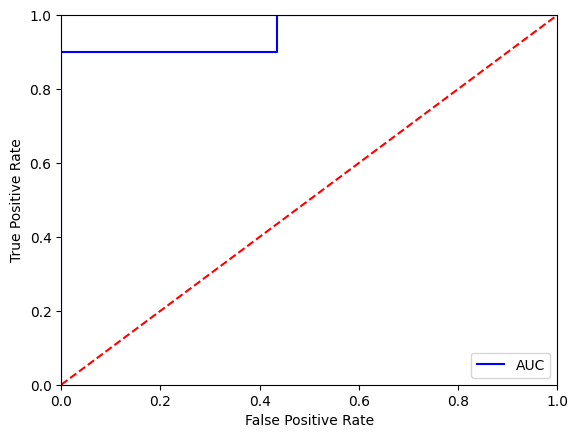

In [44]:
results = {}
# Collects performance metrics for all tasks on test set
for i in range(len(all_tasks)):
    
    valid_datapoints = y_test[:,i] >= 0
    y_test_task = y_test[valid_datapoints,i] 
    y_test_pred_task = y_test_pred[i].detach().numpy()[valid_datapoints,0]
    
    acc = accuracy_score(y_test_task, np.round(y_test_pred_task))
    print('Accuracy for MTDNN on Morgan Fingerprint:', acc)
    
    bacc = sk.metrics.balanced_accuracy_score(y_test_task, np.round(y_test_pred_task))

    f1 = f1_score(y_test_task, np.round(y_test_pred_task), pos_label=1)
    print('F1 for MTDNN on Morgan Fingerprint:', f1)

    cfm = sk.metrics.confusion_matrix(y_test_task, np.round(y_test_pred_task))
    cfm = cfm.astype('float') / cfm.sum(axis=1)[:, np.newaxis]
    
    tn, fp, fn, tp = cfm.ravel()
    pr = tp / (tp + fp)
    rc = tp / (tp + fn)
    print(' True Positive:', tp)
    print(' True Negative:', tn)
    print('False Positive:', fp)
    print('False Negative:', fn)
    
    
    auc = roc_auc_score(y_test_task, y_test_pred_task)
    print('Test ROC AUC ({}):'.format(all_tasks[i]), auc)
    
    results[all_tasks[i]] = [auc, acc, bacc, tn, tp, pr, rc, f1]

    fpr, tpr, threshold = sk.metrics.roc_curve(y_test_task, y_test_pred_task)
    plt.plot(fpr, tpr, 'b', label = 'AUC')
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()

In [45]:
print('Task'.ljust(10), '\t', '  AUC ', ' ACC ', ' BACC ', ' TN  ', ' TP  ', ' PR  ', ' RC  ', ' F1  ')
for task, auc in results.items():
    print(task.ljust(10), '\t', np.round(auc,3))

Task       	   AUC   ACC   BACC   TN    TP    PR    RC    F1  
CT_TOX     	 [0.956 0.98  0.85  1.    0.7   1.    0.7   0.824]


##### See Valid set performance

In [46]:
# print test loss
for x_valid_torch, y_valid_torch in valid_generator:
    y_valid_pred = model.eval().to(device).cpu()(x_valid_torch)
    
    # Compute loss over all tasks
    loss = 0
    for i in range(len(all_tasks)):
        y_test_task = y_valid_torch[:,i]
        y_pred_task  = y_valid_pred[i][:,0]

        # compute loss for labels that are not NA
        indice_valid = y_test_task >= 0
        loss_task = criterion(y_pred_task[indice_valid], y_test_task[indice_valid]) / N_test[i]

        loss += loss_task
    
print(loss.item())

0.004917023237794638


Accuracy for deepnn on Morgan Fingerprint: 0.9798657718120806
F1 for deepnn on Morgan Fingerprint: 0.8421052631578948
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[1.         0.        ]
 [0.27272727 0.72727273]]
 True Positive: 0.7272727272727273
 True Negative: 1.0
False Positive: 0.0
False Negative: 0.2727272727272727
Test ROC AUC (CT_TOX): 0.7667984189723321


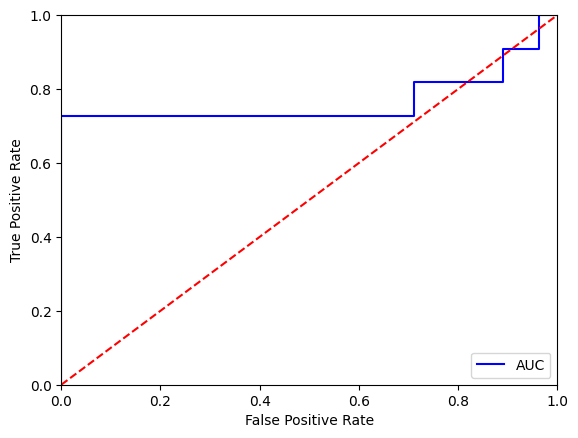

In [47]:
results_valid = {}
# Collects performance metrics for all tasks on Valid set
for i in range(len(all_tasks)):
    
    valid_datapoints = y_valid[:,i] >= 0
    y_valid_task = y_valid[valid_datapoints,i] 
    y_valid_pred_task = y_valid_pred[i].detach().numpy()[valid_datapoints,0]
    
    
    acc = accuracy_score(y_valid_task, np.round(y_valid_pred_task))
    print('Accuracy for deepnn on Morgan Fingerprint:', acc)
    
    bacc = sk.metrics.balanced_accuracy_score(y_valid_task, np.round(y_valid_pred_task))

    f1 = f1_score(y_valid_task, np.round(y_valid_pred_task), pos_label=1)
    print('F1 for deepnn on Morgan Fingerprint:', f1)

    cfm = sk.metrics.confusion_matrix(y_valid_task, np.round(y_valid_pred_task))
    cfm = cfm.astype('float') / cfm.sum(axis=1)[:, np.newaxis]

    print('Confusion Matrix for deepnn on Morgan Fingerprint:\n', cfm)

    tn, fp, fn, tp = cfm.ravel()
    pr = tp / (tp + fp)
    rc = tp / (tp + fn)
    print(' True Positive:', tp)
    print(' True Negative:', tn)
    print('False Positive:', fp)
    print('False Negative:', fn)
    
    
    auc = roc_auc_score(y_valid_task, y_valid_pred_task)
    print('Test ROC AUC ({}):'.format(all_tasks[i]), auc)
    
    results_valid[all_tasks[i]] = [auc, acc, bacc, tn, tp, pr, rc, f1]

    fpr, tpr, threshold = sk.metrics.roc_curve(y_valid_task, y_valid_pred_task)
    plt.plot(fpr, tpr, 'b', label = 'AUC')
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()

In [48]:
print('Task'.ljust(10), '\t', '  AUC ', ' ACC ', ' BACC ', ' TN  ', ' TP  ', ' PR  ', ' RC  ', ' F1  ')
for task, auc in results_valid.items():
    print(task.ljust(10), '\t', np.round(auc,3))

Task       	   AUC   ACC   BACC   TN    TP    PR    RC    F1  
CT_TOX     	 [0.767 0.98  0.864 1.    0.727 1.    0.727 0.842]
